HEART ATTACK PREDICTION USING LOGISTIC REGRESSION

Dataset Size: ~1300 Records

Algorithm: Logistic Regression

Import Libraries

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score, f1_score, classification_report


Load Dataset

In [2]:
df = pd.read_csv('Medicaldataset.csv')
df.head(5)

df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1319 non-null   int64  
 1   Gender                    1319 non-null   int64  
 2   Heart_rate                1319 non-null   int64  
 3   Systolic_blood_pressure   1319 non-null   int64  
 4   Diastolic_blood_pressure  1319 non-null   int64  
 5   Blood_sugar               1319 non-null   float64
 6   CK-MB                     1319 non-null   float64
 7   Troponin                  1319 non-null   float64
 8   Result                    1319 non-null   str    
dtypes: float64(3), int64(5), str(1)
memory usage: 103.2 KB


Age                         0
Gender                      0
Heart_rate                  0
Systolic_blood_pressure     0
Diastolic_blood_pressure    0
Blood_sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

EDA :- Visualization

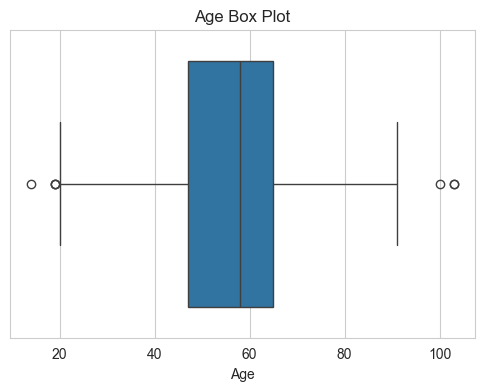

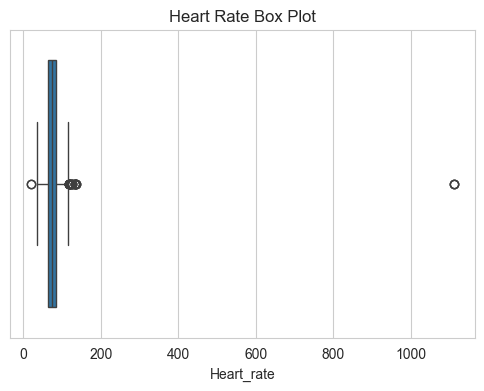

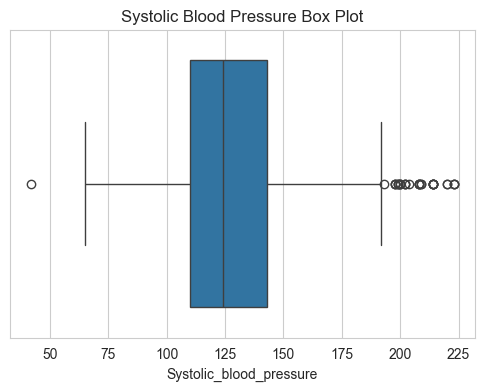

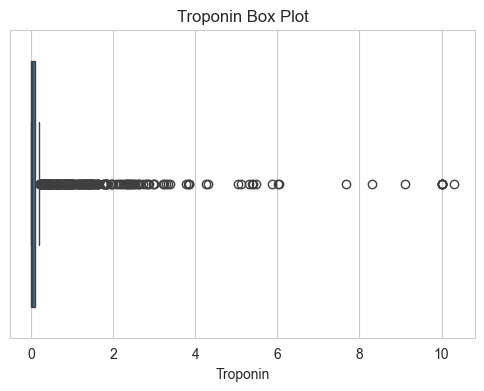

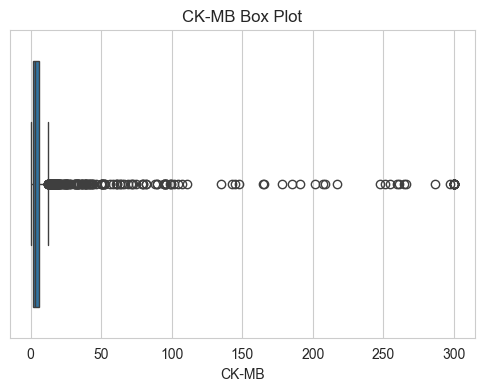

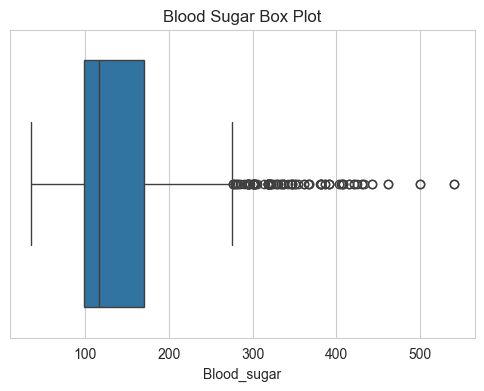

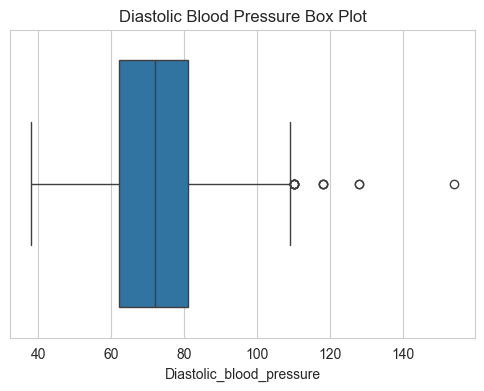

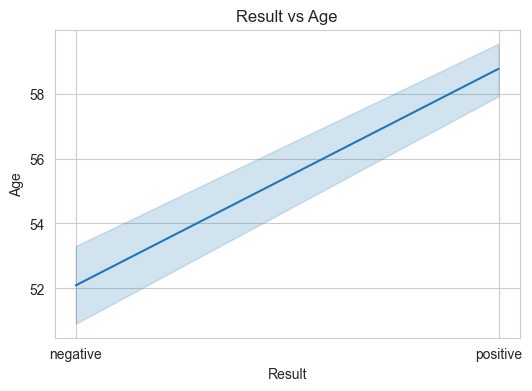

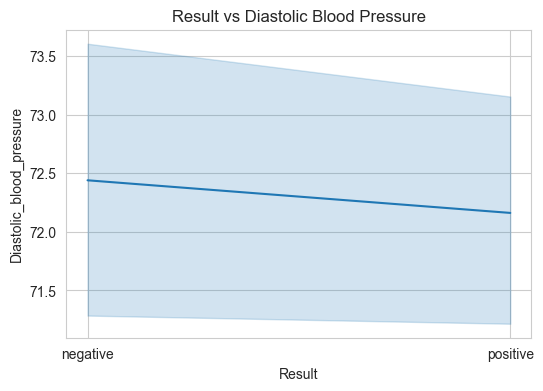

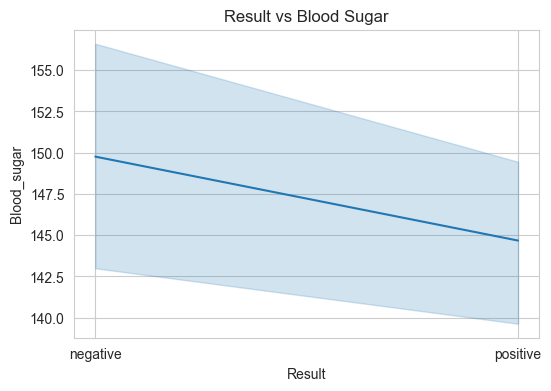

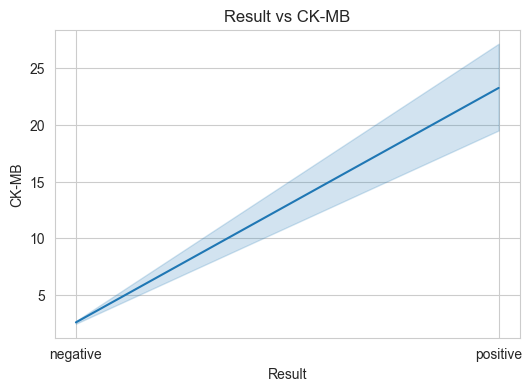

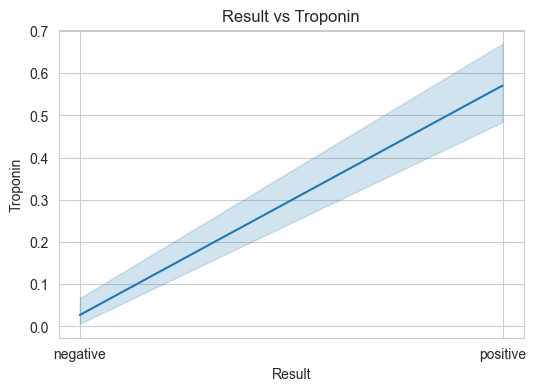

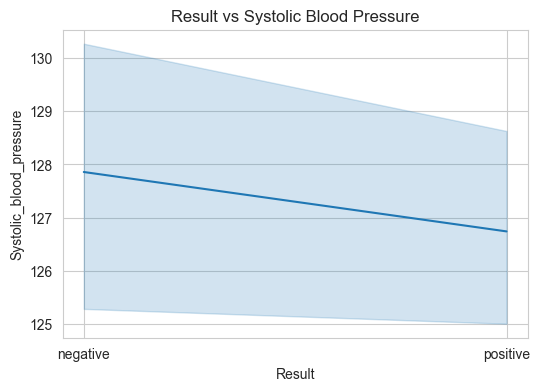

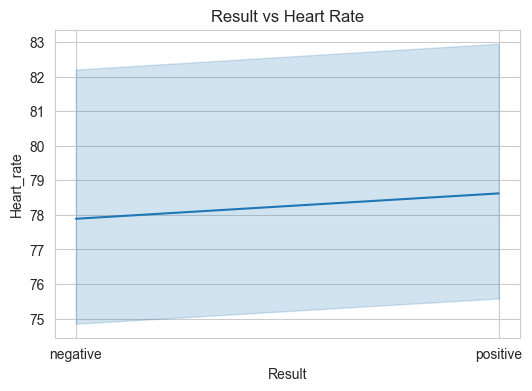

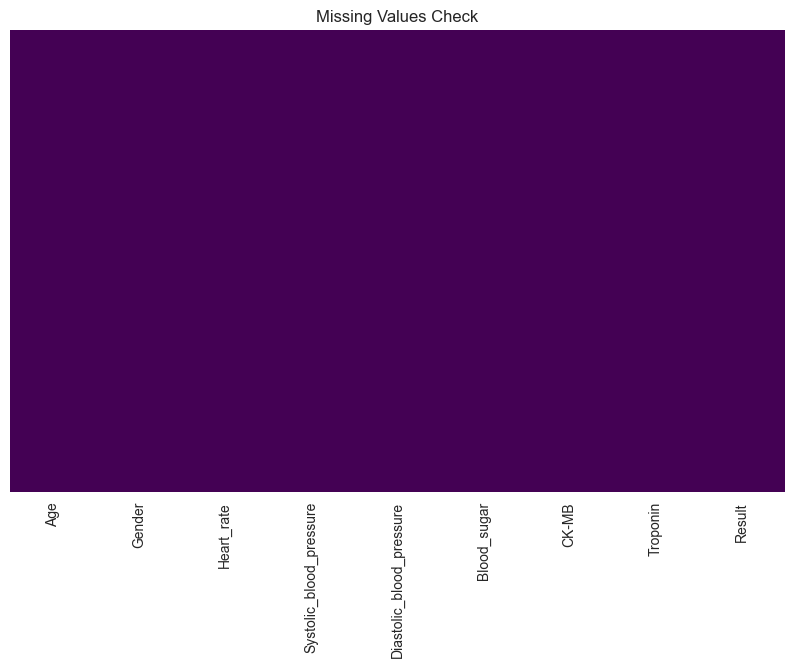

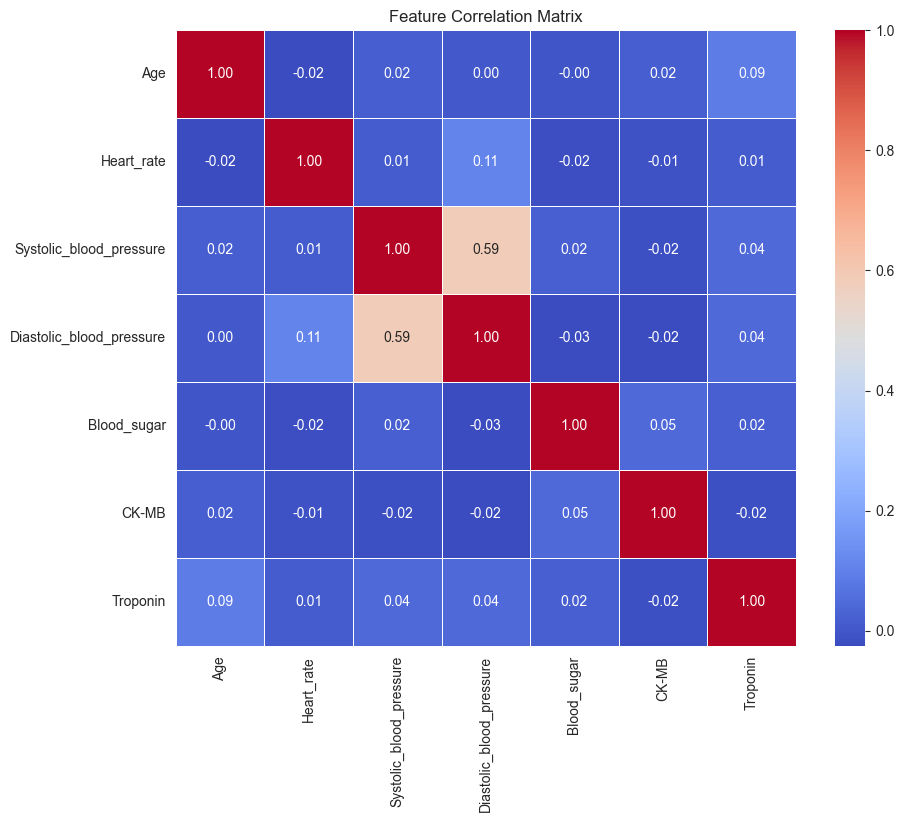

In [3]:
sns.set_style('whitegrid')


plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Age Box Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Heart_rate'])
plt.title("Heart Rate Box Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Systolic_blood_pressure'])
plt.title("Systolic Blood Pressure Box Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Troponin'])
plt.title("Troponin Box Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['CK-MB'])
plt.title("CK-MB Box Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Blood_sugar'])
plt.title("Blood Sugar Box Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Diastolic_blood_pressure'])
plt.title("Diastolic Blood Pressure Box Plot")
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(x='Result', y='Age', data=df)
plt.title("Result vs Age")
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(x='Result', y='Diastolic_blood_pressure', data=df)
plt.title("Result vs Diastolic Blood Pressure")
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(x='Result', y='Blood_sugar', data=df)
plt.title("Result vs Blood Sugar")
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(x='Result', y='CK-MB', data=df)
plt.title("Result vs CK-MB")
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(x='Result', y='Troponin', data=df)
plt.title("Result vs Troponin")
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(x='Result', y='Systolic_blood_pressure', data=df)
plt.title("Result vs Systolic Blood Pressure")
plt.show()

plt.figure(figsize=(6,4))
sns.lineplot(x='Result', y='Heart_rate', data=df)
plt.title("Result vs Heart Rate")
plt.show()

plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Missing Values Check")
plt.show()

plt.figure(figsize=(10, 8))

# Calculate the correlation matrix
corr_matrix = df[['Age', 'Heart_rate', 'Systolic_blood_pressure', 
                  'Diastolic_blood_pressure', 'Blood_sugar', 'CK-MB', 'Troponin']].corr()


sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()



Encoding

In [4]:
le = LabelEncoder()
df_encoded = df.copy()

df_encoded['Result_encoded'] = le.fit_transform(df_encoded[['Result']])
df_encoded['Gender_encoded'] = le.fit_transform(df_encoded[['Gender']])

df_encoded.head(5)

C:\Users\SAURODEEP DE\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\SAURODEEP DE\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Age,Gender,Heart_rate,Systolic_blood_pressure,Diastolic_blood_pressure,Blood_sugar,CK-MB,Troponin,Result,Result_encoded,Gender_encoded
0,64,1,66,160,83,160.0,1.80,0.012,negative,0,1
1,21,1,94,98,46,296.0,6.75,1.060,positive,1,1
2,55,1,64,160,77,270.0,1.99,0.003,negative,0,1
3,64,1,70,120,55,270.0,13.87,0.122,positive,1,1
4,55,1,64,112,65,300.0,1.08,0.003,negative,0,1


Feature Selection

In [5]:
X = df_encoded[
    [
        'Age',
        'Gender_encoded',
        'Heart_rate',
        'Systolic_blood_pressure',
        'Diastolic_blood_pressure',
        'Blood_sugar',
        'CK-MB',
        'Troponin'
    ]
]
y = df_encoded['Result_encoded']

Train-Test-Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

Save Cleaned Data

In [7]:
joblib.dump((X_train, X_test, y_train, y_test), 'cleaned_data.pkl')

['cleaned_data.pkl']

In [8]:
'''
# Fast load your pre-cleaned data splits
X_train, X_test, y_train, y_test = joblib.load('cleaned_data.pkl')

'''

"\n# Fast load your pre-cleaned data splits\nX_train, X_test, y_train, y_test = joblib.load('cleaned_data.pkl')\n\n"

Train Model

In [9]:
model = LogisticRegression()

model.fit(X_train, y_train)

C:\Users\SAURODEEP DE\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Save Model

In [10]:
joblib.dump(model, 'logistic_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [11]:
'''
# Load the saved model
loaded_model = joblib.load('logistic_model.pkl')

# Use it immediately to predict or score
predictions = loaded_model.predict(X_test)
accuracy = loaded_model.score(X_test, y_test)
print(f"Loaded model accuracy: {accuracy}")
'''

'\n# Load the saved model\nloaded_model = joblib.load(\'logistic_model.pkl\')\n\n# Use it immediately to predict or score\npredictions = loaded_model.predict(X_test)\naccuracy = loaded_model.score(X_test, y_test)\nprint(f"Loaded model accuracy: {accuracy}")\n'

Prediction

In [13]:
predictions = model.predict(X_test)

print("Predictions:", predictions)
print("Actual Values:", y_test)

Predictions: [1 0 0 0 1 1 1 1 1 1 0 0 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 0 0 1 1 0 1 0 1
 1 0 1 1 0 1 0 1 1 1 1 0 1 0 1 0 0 0 1 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 1 1 1 0 1 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1
 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 1 0 1 0 0 0 1 0 1 0 1 1 1 0 0 1
 0 0 1 0 1 1 1 1 0 1 1 0 0 1 0 0 1 1 0 0 0 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1
 1 1 0 0 1 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 0
 0 1 1 1 0 1 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 1 1 0 1
 0 0 1 1 0]
Actual Values: 677     1
1046    0
610     0
49      0
1284    1
       ..
1176    0
1002    0
1159    1
542     1
170     1
Name: Result_encoded, Length: 264, dtype: int64


Model Evaluation

In [14]:
accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions)
cr = classification_report(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print("Accuracy:", accuracy)
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(cr)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

Accuracy: 0.803030303030303
Confusion Matrix:
[[ 73  28]
 [ 24 139]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.72      0.74       101
           1       0.83      0.85      0.84       163

    accuracy                           0.80       264
   macro avg       0.79      0.79      0.79       264
weighted avg       0.80      0.80      0.80       264

Precision: 0.8323353293413174
Recall: 0.852760736196319
F1-Score: 0.8424242424242424
